# 02 - Advanced EDA Dashboard

Train-only dashboard for detailed exploratory analysis.

Data scope:
- `review_id`
- `product_name`
- `content_raw`
- `content`
- label columns

Visualizations covered:
- emoji usage by sentiment
- sentiment pie chart
- raw vs clean word-count histogram
- aspect coverage and sentiment structure
- PygWalker exploration
- n-gram dashboards
- word clouds
- 3D TF-IDF + t-SNE projection

## GitHub Preview Snapshot

![Dataset snapshot](assets/eda_snapshot.png)

This static snapshot keeps the notebook readable in GitHub preview. Run the notebook locally for the interactive Plotly sections below.


In [28]:
from pathlib import Path
import json
import math
import statistics

from IPython import get_ipython
import emoji
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from IPython.display import display
from wordcloud import WordCloud

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "legend.frameon": False,
    }
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)


In [29]:
def avg_word_len(text: str) -> float:
    words = text.split()
    if not words:
        return 0.0
    return float(np.mean([len(word) for word in words]))


def count_emojis(text: str) -> int:
    try:
        return len(emoji.emoji_list(text))
    except Exception:
        return 0


def normalize_text_for_ngrams(text: str) -> str:
    text = text.lower()
    text = " ".join(text.split())
    return text


def sentiment_subset(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    return frame.loc[frame["sentiment_name"] == label].copy()


def top_ngrams(texts, ngram_range=(2, 2), top_n=15):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b[\w_]+\b",
        min_df=2,
    )
    matrix = vectorizer.fit_transform(texts)
    if matrix.shape[1] == 0:
        return pd.DataFrame(columns=["ngram", "count"])
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    items = pd.DataFrame(
        {
            "ngram": vectorizer.get_feature_names_out(),
            "count": counts,
        }
    )
    return items.sort_values("count", ascending=False).head(top_n)


def style_axes(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, color="#dfe3eb", linewidth=0.8, alpha=0.9)


def annotate_vertical_bars(ax, bars, values, fmt="{:,.0f}", offset_ratio=0.015, fontsize=10):
    values = list(values)
    peak = max(values) if values else 0
    offset = peak * offset_ratio if peak else 0.01
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


def annotate_horizontal_bars(ax, bars, values, fmt="{:,.0f}", offset_ratio=0.01, fontsize=10):
    values = list(values)
    peak = max(values) if values else 0
    offset = peak * offset_ratio if peak else 0.01
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(value),
            ha="left",
            va="center",
            fontsize=fontsize,
        )


In [30]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
        if (candidate / "preprocessing_pipeline.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root")


ROOT = find_project_root()
DATA_PATH = ROOT / "data/processed/train_clean.json"

df = pd.read_json(DATA_PATH)
keep_cols = [
    "review_id",
    "product_name",
    "content_raw",
    "content",
    "sentiment_llm",
    "as_content",
    "as_physical",
    "as_price",
    "as_packaging",
    "as_delivery",
    "as_service",
]
keep_cols = list(dict.fromkeys(col for col in keep_cols if col in df.columns))
df = df[keep_cols].copy()

ID_COL = "review_id" if "review_id" in df.columns else "product_id"
PRODUCT_COL = "product_name" if "product_name" in df.columns else ID_COL

SENTIMENT_MAP = {0: "negative", 1: "neutral", 2: "positive"}
SENTIMENT_ORDER = ["negative", "neutral", "positive"]
SENTIMENT_COLORS = {
    "negative": "#d64b4b",
    "neutral": "#f0ad4e",
    "positive": "#2ca02c",
}

ASPECT_COLS = [
    "as_content",
    "as_physical",
    "as_price",
    "as_packaging",
    "as_delivery",
    "as_service",
]

df[PRODUCT_COL] = df[PRODUCT_COL].fillna("").astype(str)
df["content_raw"] = df["content_raw"].fillna("").astype(str)
df["content"] = df["content"].fillna("").astype(str)

print(f"Loaded {len(df):,} rows x {len(df.columns)} columns")
print(f"ID_COL={ID_COL} | PRODUCT_COL={PRODUCT_COL}")
print(f"Sentiment classes: {', '.join(SENTIMENT_ORDER)}")


Loaded 10,696 rows x 11 columns
ID_COL=review_id | PRODUCT_COL=product_name
Sentiment classes: negative, neutral, positive


In [31]:
df["sentiment_name"] = df["sentiment_llm"].map(SENTIMENT_MAP).fillna("unknown")
df["raw_word_count"] = df["content_raw"].apply(lambda x: len(x.split()))
df["raw_char_count"] = df["content_raw"].str.len()
df["word_count"] = df["content"].apply(lambda x: len(x.split()))
df["char_count"] = df["content"].str.len()
df["avg_word_len"] = df["content"].apply(avg_word_len)
df["lexical_diversity"] = df["content"].apply(lambda x: len(set(x.split())) / (len(x.split()) + 1))
df["caps_ratio"] = df["content"].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
df["emoji_count_raw"] = df["content_raw"].apply(count_emojis)
df["char_delta"] = df["raw_char_count"] - df["char_count"]
df["word_delta"] = df["raw_word_count"] - df["word_count"]
df["review_length_bucket"] = pd.cut(
    df["char_count"],
    bins=[0, 10, 20, 50, 100, 200, 500, 10_000],
    right=False,
)

display(
    df[
        [
            ID_COL,
            PRODUCT_COL,
            "sentiment_name",
            "content_raw",
            "content",
            "word_count",
            "char_count",
            "avg_word_len",
            "lexical_diversity",
            "caps_ratio",
    ]
].head(8)
)

,review_id,product_name,sentiment_name,content_raw,content,word_count,char_count,avg_word_len,lexical_diversity,caps_ratio
0,14357443,Sách Xứ Cát,neutral,"Sản phẩm thật sự chất lượng, và Tiki giao hàng nhanh như mọi khi. Tuy nhiên có đôi chỗ trong truyện dịch khá giống máy, tạo cảm giác kì cục","Sản phẩm thật sự chất lượng, và Tiki giao hàng nhanh như mọi khi. Tuy nhiên có đôi chỗ trong truyện dịch khá giống máy, tạo cảm giác kì cục",30,139,3.666667,0.967742,0.021429
1,16749123,Bộ sách Làm Giàu Từ Chứng Khoán (How To Make Money In Stock) phiên bản mới + Hướng Dẫn Thực Hành CANSLIM Cho Người Mới Bắt Đầu,negative,Ko phù hợp đầu tư dài hạn,không phù hợp đầu tư dài hạn,7,28,3.142857,0.875000,0.000000
2,897166,Sách Predictably Irrational : The Hidden Forces That Shape Our Decisions (Revised and Updated Edition),negative,"Cuốn sách không đúng khổ ghi trên thông tin, khổ rất nhỏ như sổ tay và bìa chất lượng kém. yêu cầu tiki ghi đúng số liệu cuốn sách","Cuốn sách không đúng khổ ghi trên thông tin, khổ rất nhỏ như sổ tay và bìa chất lượng kém. yêu cầu tiki ghi đúng số liệu cuốn sách",29,130,3.517241,0.833333,0.007634
3,9105241,Siêu Cò – How To Be A Power Connector,neutral,"Sách hay, nội dung hấp dẫn, thiết thực.\nChấm 5 sao.\nGiao hàng nhanh, tốt.\nTuy nhiên phần Bookcare làm ẩu, dính bẩn lem nhem như hình.","Sách hay, nội dung hấp dẫn, thiết thực. Chấm 5 sao. Giao hàng nhanh, tốt. Tuy nhiên phần book_care làm ẩu, dính bẩn lem nhem như hình.",27,134,4.000000,0.964286,0.029630
4,6820537,Sách Elon Musk: How The Billionaire CEO Of Spacex And Tesla Is Shaping Our Future,neutral,sách chất lượng in chưa được cao,sách chất lượng in chưa được cao,7,32,3.714286,0.875000,0.000000
5,2621588,Sách 22 Chuyên Đề Hay Và Khó - Bồi Dưỡng Học Sinh Giỏi Hóa Học THCS (Tập 1) (Tái Bản),negative,Vừa nhận sách xong và thấy bị ngược. Về nội dung thì khỏi bàn,Vừa nhận sách xong và thấy bị ngược. Về nội dung thì khỏi bàn,14,61,3.428571,0.933333,0.032258
6,18951591,Sách TÂM LÝ HỌC ỨNG DỤNG,neutral,Đang dùng dk đang đọc sẽ tìm hiểu thêm,Đang dùng đăng_ký đang đọc sẽ tìm hiểu thêm,9,43,3.888889,0.900000,0.022727
7,12251303,Sách Blue Ocean Strategy - Chiến Lược Đại Dương Xanh (Bìa Cứng) (Tái Bản),negative,sách cấn bìa và bẩn nhiều quá,sách cấn bìa và bẩn nhiều quá,7,29,3.285714,0.875000,0.000000


## Random Review Explorer

review_id: 10449780
product_name: Mình Chỉ Là Người Bình Thường (Sách Tô Màu)
sentiment: negative

RAW:
Hàng tổ, phù hợp giá tiền,

CLEAN:
Hàng tổ, phù hợp giá tiền,

Same product reviews: 328


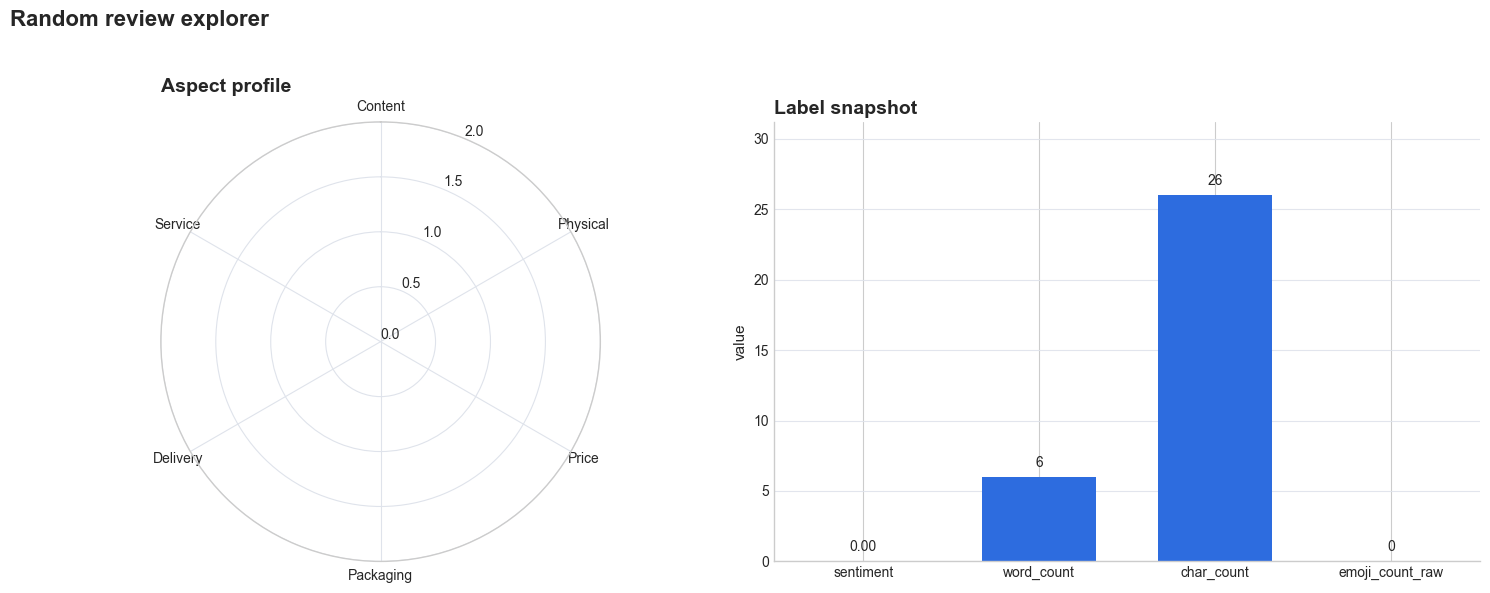

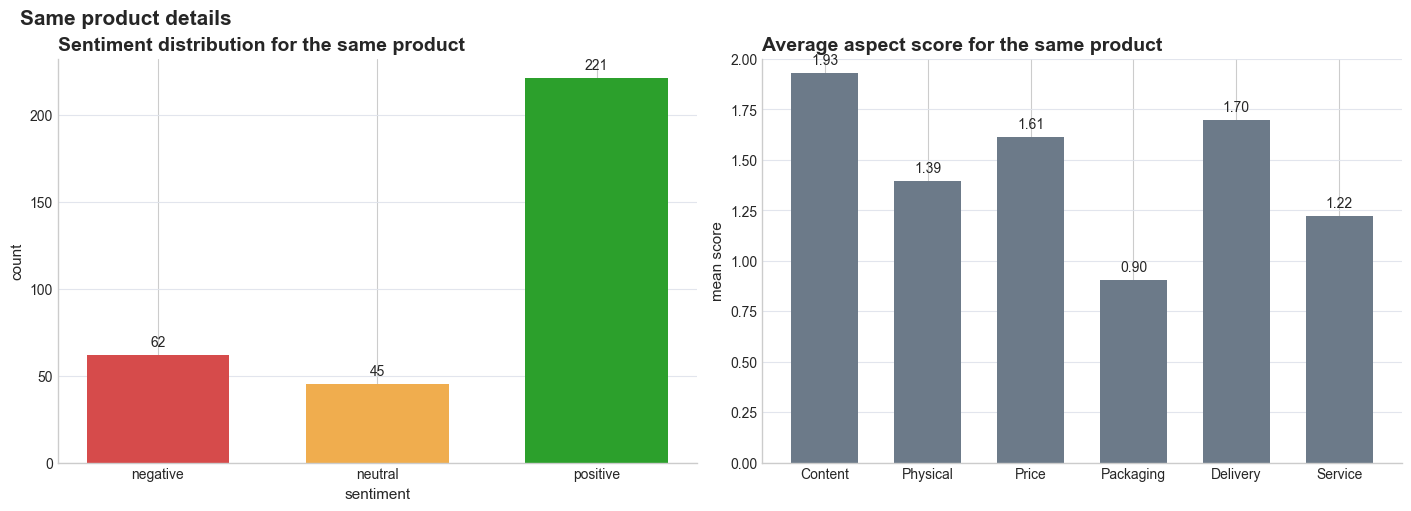

,review_id,product_name,sentiment_name,content_raw,content,word_count,char_count
8,10278055,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),positive,"giao hàng siêu nhanh luôn í, mình mới đặt hôm qua mà nay đã có rồi ^^ đặt ngay hôm sách sale 50% nên giá siêu mềm, sách rất đẹp luôn ạ t...","giao hàng siêu nhanh luôn í, mình mới đặt hôm qua mà nay đã có rồi ^^ đặt ngay hôm sách sale 50% nên giá siêu mềm, sách rất đẹp luôn ạ t...",39,162
24,18091417,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),neutral,"Sách mới, nội dung thong thả, thong thả tô thong thả chơi mèo.","Sách mới, nội dung thong thả, thong thả tô thong thả chơi mèo.",13,62
71,10730688,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),neutral,"Giao hàng nhanh tuy nhiên sách bị cong,hằn và vì bìa khá cứng nên k sửa được","Giao hàng nhanh tuy nhiên sách bị cong,hằn và vì bìa khá cứng nên không sửa được",17,80
72,9858398,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),negative,sách bị cong mấy góc hết :)),sách bị cong mấy góc hết :)),7,28
95,13653120,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),positive,sách rất đẹp nha giao hàng ok cho 5 sao,sách rất đẹp nha giao hàng ok cho 5 sao,10,39
124,9562745,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),positive,"sách của kulzsc xinh ơi là xinh, giao hàng nhanh lắm ❣️","sách của kulzsc xinh ơi là xinh, giao hàng nhanh lắm emoji_heart_exclamation",12,76
132,18970075,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),positive,"Đặt tối hôm trước, sáng hôm sau có ngay hàng, dù mình không chọn giao siêu tốc mà chỉ chọn giao tiết kiệm.\nCuốn sách nhẹ nhàng, dễ thươ...","Đặt tối hôm trước, sáng hôm sau có ngay hàng, dù mình không chọn giao siêu tốc mà chỉ chọn giao tiết kiệm. Cuốn sách nhẹ nhàng, dễ thươn...",35,168
139,9869701,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),neutral,"ưng cực kì ạ,đóng gói chưa cẩn thận lắm","ưng cực kì ạ,đóng gói chưa cẩn thận lắm",9,39
150,13980688,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),positive,sách đẹp dã man luoonnnnnnnnnnn,sách đẹp dã man luoon,5,21
167,14108220,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),positive,Sách tô vui,Sách tô vui,3,11


In [32]:
random_idx = np.random.RandomState(42).choice(df.index)
sample_row = df.loc[random_idx]
same_product = df.loc[df[PRODUCT_COL] == sample_row[PRODUCT_COL]].copy()
review_key = sample_row.get(ID_COL, random_idx)

print(f"{ID_COL}: {review_key}")
print(f"{PRODUCT_COL}: {sample_row[PRODUCT_COL]}")
print(f"sentiment: {sample_row['sentiment_name']}")
print("\nRAW:")
print(sample_row["content_raw"])
print("\nCLEAN:")
print(sample_row["content"])
print(f"\nSame product reviews: {len(same_product)}")

aspect_values = sample_row[ASPECT_COLS].fillna(0).astype(float).tolist()
angles = np.linspace(0, 2 * np.pi, len(ASPECT_COLS), endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])
aspect_values_closed = aspect_values + [aspect_values[0]]
label_snapshot = pd.DataFrame(
    {
        "label": ["sentiment", "word_count", "char_count", "emoji_count_raw"],
        "value": [
            float(sample_row["sentiment_llm"]),
            float(sample_row["word_count"]),
            float(sample_row["char_count"]),
            float(sample_row["emoji_count_raw"]),
        ],
    }
)

fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1])
ax1 = fig.add_subplot(gs[0, 0], projection="polar")
ax2 = fig.add_subplot(gs[0, 1])

ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
ax1.plot(angles_closed, aspect_values_closed, color="#2d6cdf", linewidth=2)
ax1.fill(angles_closed, aspect_values_closed, color="#2d6cdf", alpha=0.18)
ax1.set_xticks(angles)
ax1.set_xticklabels([aspect.replace("as_", "").capitalize() for aspect in ASPECT_COLS])
ax1.set_yticks([0, 0.5, 1.0, 1.5, 2.0])
ax1.set_ylim(0, 2)
ax1.set_title("Aspect profile", loc="left")
ax1.grid(color="#dfe3eb", linewidth=0.8)

bar_labels = label_snapshot["label"].tolist()
bar_values = label_snapshot["value"].tolist()
bar_colors = ["#e45756", "#2d6cdf", "#2d6cdf", "#4caf50"]
bars = ax2.bar(bar_labels, bar_values, color=bar_colors, width=0.65)
style_axes(ax2)
ax2.set_title("Label snapshot", loc="left")
ax2.set_ylabel("value")
ax2.set_ylim(0, max(bar_values) * 1.2 if bar_values else 1)
for bar, label, value in zip(bars, bar_labels, bar_values):
    fmt = "{:.2f}" if label == "sentiment" else "{:,.0f}"
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (max(bar_values) * 0.02 if bar_values else 0.01),
        fmt.format(value),
        ha="center",
        va="bottom",
        fontsize=10,
    )

fig.suptitle("Random review explorer", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

if len(same_product) > 1:
    product_summary = (
        same_product.groupby("sentiment_name")
        .size()
        .reindex(SENTIMENT_ORDER)
        .fillna(0)
        .reset_index(name="count")
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    ax = axes[0]
    x = np.arange(len(product_summary))
    counts = product_summary["count"].tolist()
    bars = ax.bar(x, counts, color=[SENTIMENT_COLORS[label] for label in product_summary["sentiment_name"]], width=0.65)
    ax.set_xticks(x)
    ax.set_xticklabels(product_summary["sentiment_name"])
    style_axes(ax)
    ax.set_title("Sentiment distribution for the same product", loc="left")
    ax.set_xlabel("sentiment")
    ax.set_ylabel("count")
    annotate_vertical_bars(ax, bars, counts, fmt="{:,.0f}")

    ax = axes[1]
    aspect_means_product = same_product[ASPECT_COLS].mean().reset_index()
    aspect_means_product.columns = ["aspect", "mean_score"]
    x = np.arange(len(aspect_means_product))
    means = aspect_means_product["mean_score"].tolist()
    bars = ax.bar(x, means, color="#6c7a89", width=0.65)
    ax.set_xticks(x)
    ax.set_xticklabels([aspect.replace("as_", "").capitalize() for aspect in aspect_means_product["aspect"]])
    style_axes(ax)
    ax.set_title("Average aspect score for the same product", loc="left")
    ax.set_ylabel("mean score")
    ax.set_ylim(0, 2)
    annotate_vertical_bars(ax, bars, means, fmt="{:.2f}")

    fig.suptitle("Same product details", x=0.01, ha="left", fontsize=15, fontweight="bold")
    plt.show()

display_cols = [
    col
    for col in [ID_COL, PRODUCT_COL, "sentiment_name", "content_raw", "content", "word_count", "char_count"]
    if col in same_product.columns
]
display(same_product[display_cols].head(10))


## Bar Chart: Average Emoji Count by Sentiment

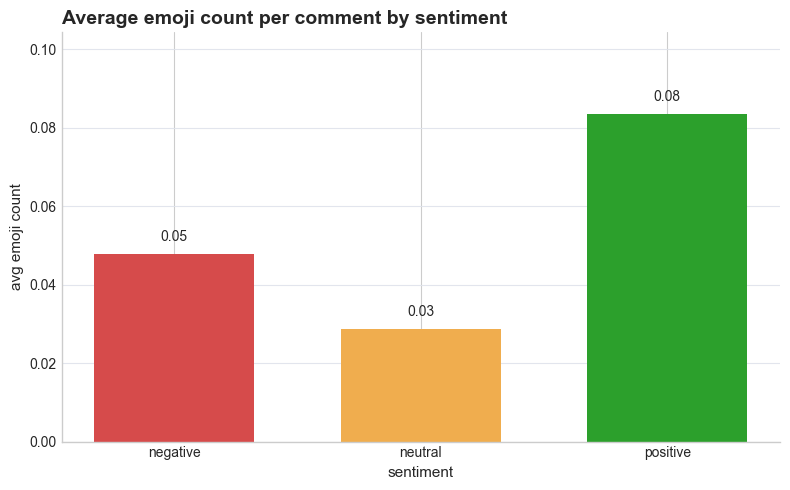

In [33]:
emoji_by_sentiment = (
    df.groupby("sentiment_name")["emoji_count_raw"]
    .mean()
    .reindex(SENTIMENT_ORDER)
    .fillna(0)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
labels = emoji_by_sentiment["sentiment_name"].tolist()
values = emoji_by_sentiment["emoji_count_raw"].tolist()
bars = ax.bar(np.arange(len(labels)), values, color=[SENTIMENT_COLORS[label] for label in labels], width=0.65)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
style_axes(ax)
ax.set_title("Average emoji count per comment by sentiment", loc="left")
ax.set_xlabel("sentiment")
ax.set_ylabel("avg emoji count")
ax.set_ylim(0, max(values) * 1.25 if values else 1)
annotate_vertical_bars(ax, bars, values, fmt="{:.2f}", offset_ratio=0.03)
plt.tight_layout()
plt.show()


## Pie Chart: Sentiment Distribution

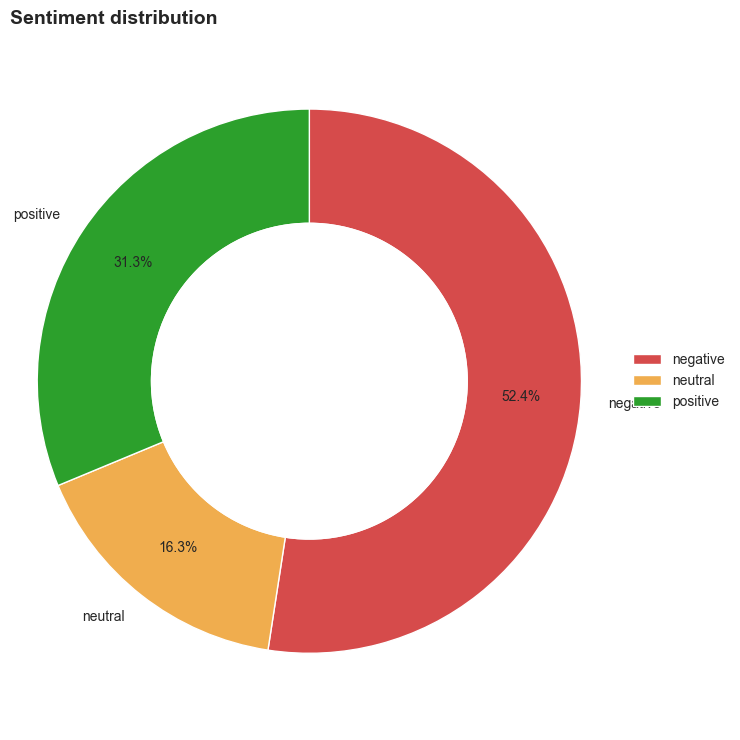

In [34]:
sentiment_counts = (
    df["sentiment_name"]
    .value_counts()
    .reindex(SENTIMENT_ORDER)
    .fillna(0)
    .astype(int)
    .reset_index()
)
sentiment_counts.columns = ["sentiment_name", "count"]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
labels = sentiment_counts["sentiment_name"].tolist()
values = sentiment_counts["count"].tolist()
colors = [SENTIMENT_COLORS[label] for label in labels]
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct=lambda pct: f"{pct:.1f}%",
    pctdistance=0.78,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
)
ax.add_artist(plt.Circle((0, 0), 0.58, color="white"))
ax.set_title("Sentiment distribution", loc="left")
ax.axis("equal")
ax.legend(wedges, labels, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


## Histogram: Raw vs Clean Word Count

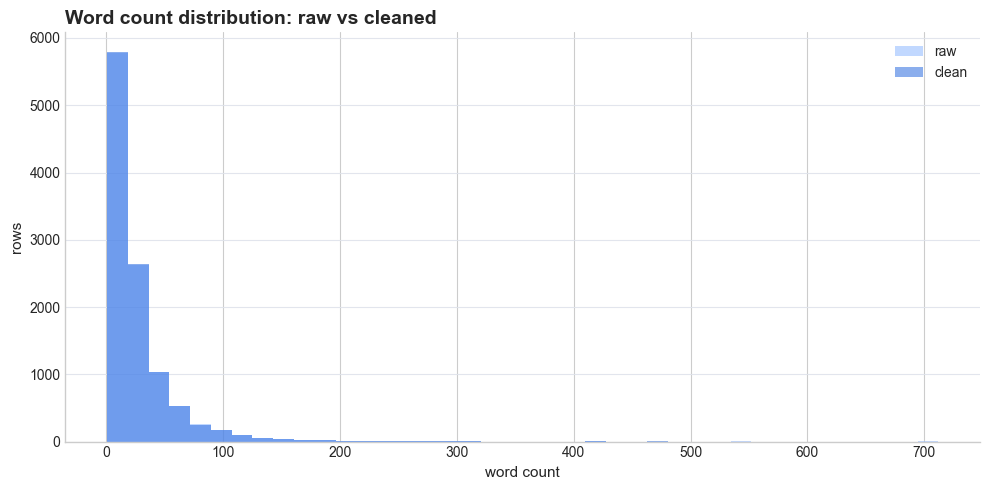

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["raw_word_count"], bins=40, alpha=0.55, label="raw", color="#8fb8ff")
ax.hist(df["word_count"], bins=40, alpha=0.55, label="clean", color="#2d6cdf")
style_axes(ax)
ax.set_title("Word count distribution: raw vs cleaned", loc="left")
ax.set_xlabel("word count")
ax.set_ylabel("rows")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Data Preview


In [36]:
explore_df = df[
    [
        ID_COL,
        PRODUCT_COL,
        "content_raw",
        "content",
        "sentiment_name",
        "word_count",
        "char_count",
        "avg_word_len",
        "lexical_diversity",
        "caps_ratio",
        "emoji_count_raw",
    ]
].copy()

preview_df = explore_df.sample(min(len(explore_df), 20), random_state=42).sort_values([PRODUCT_COL, ID_COL])
display(preview_df)


,review_id,product_name,content_raw,content,sentiment_name,word_count,char_count,avg_word_len,lexical_diversity,caps_ratio,emoji_count_raw
5247,19729384,"\t Sách Mùa hè không tên (Nguyễn Nhật Ánh) - Tặng kèm Bookmark, Tranh màu","Sách in đẹp, bao bì cẩn thận, có tặng kèm sổ tay, poster, bookmark, hơi buồn vì không có chữ ký tác giả 💯","Sách in đẹp, bao bì cẩn thận, có tặng kèm sổ tay, poster, bookmark, hơi buồn vì không có chữ ký tác giả emoji_hundred_points",positive,24,124,4.208333,0.920000,0.008000,1
6662,4743399,Bộ sách Làm Giàu Từ Chứng Khoán (How To Make Money In Stock) phiên bản mới + Hướng Dẫn Thực Hành CANSLIM Cho Người Mới Bắt Đầu,Phương pháp CANSLIM của William O'neil hay vì nó đưa cả hai yếu tố KT và CBan vào lựa chọn CP. Xong người dùng phải rất khó khăn để tìm ...,Phương pháp CANSLIM của William O'neil hay vì nó đưa cả hai yếu tố kt và CBan vào lựa chọn cp. Xong người dùng phải rất khó khăn để tìm ...,neutral,122,569,3.672131,0.788618,0.042105,0
304,17675364,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),"Cute cực, tô xong iu đời hẳn ý","Cute cực, tô xong iu đời hẳn ý",positive,8,30,2.875000,0.888889,0.032258,0
6750,20126212,Sách - Búp Sen Xanh - Bìa Cứng - Tặng Kèm Obi + Postcard Hành Trình Cứu Nước - Độc Quyền Fahasa,Vì nghe thông tin ngày 10/5 phát hành sẽ chuyển hàng đi ngay nên đã order trước để kịp đi lễ hội làng Sen. Giờ đi về luôn r thì hàng mới...,Vì nghe thông tin ngày 10/5 phát hành sẽ chuyển hàng đi ngay nên đã order trước để kịp đi lễ hội làng Sen. Giờ đi về luôn rồi thì hàng m...,negative,59,256,3.355932,0.900000,0.023346,0
7756,9390212,Sách - Tuân Tử - Nguyễn Hiến Lê (Tuyển Tập Bách Gia Tranh Minh),Rất xịn xò kkkk\nMình rất thích cách đóng gói cẩn thận của shop ?,Rất xịn xò k Mình rất thích cách đóng gói cẩn thận của shop ?,positive,15,61,3.133333,0.937500,0.032258,0
346,11781316,Sách Blue Ocean Strategy - Chiến Lược Đại Dương Xanh (Bìa Cứng) (Tái Bản),Giao rất nhanh,Giao rất nhanh,neutral,3,14,4.000000,0.750000,0.066667,0
4484,7123384,Sách Chơi Cờ Vua Cùng Bé Trò Chơi Phát Triển Toàn Diện,Phần dịch thuật hơi dỡ.,Phần dịch thuật hơi dỡ.,neutral,5,23,3.800000,0.833333,0.041667,0
10319,2735983,Sách Có Hai Con Mèo Ngồi Bên Cửa Sổ,"Mình mua trên Tiki nhiều lần rồi, lần này hơi thất vọng một xíu. Tuy Tiki giao rất nhanh, mình đặt tối hôm trước, chiều hôm sau đã giao....","Mình mua trên Tiki nhiều lần rồi, lần này hơi thất vọng một xíu. Tuy Tiki giao rất nhanh, mình đặt tối hôm trước, chiều hôm sau đã giao....",negative,66,291,3.424242,0.776119,0.020548,0
4818,17760971,Sách Ehon - Đi Đã Ngoại Ngày Mưa,"Giấy dày đẹp,hình vẽ màu sắc bắt mắt,phù hợp với trẻ em,hy vọng bé nhà mình sẽ thích,giao hàng siêu nhanh,hoàn toàn hài lòng khi mua sác...","Giấy dày đẹp,hình vẽ màu sắc bắt mắt,phù hợp với trẻ em,hy vọng bé nhà mình sẽ thích,giao hàng siêu nhanh,hoàn toàn hài lòng khi mua sác...",positive,29,146,4.068966,0.966667,0.013605,0
107,7909097,Sách Hachiko - Chú Chó Đợi Chờ (Bìa Mềm) (Tái Bản 2019),"sách đẹp, có minh hoạ tranh màu rất đẹp. mình hài lòng.","sách đẹp, có minh hoạ tranh màu rất đẹp. mình hài lòng.",positive,12,55,3.666667,0.923077,0.000000,0


## Bar Chart: Aspect Coverage

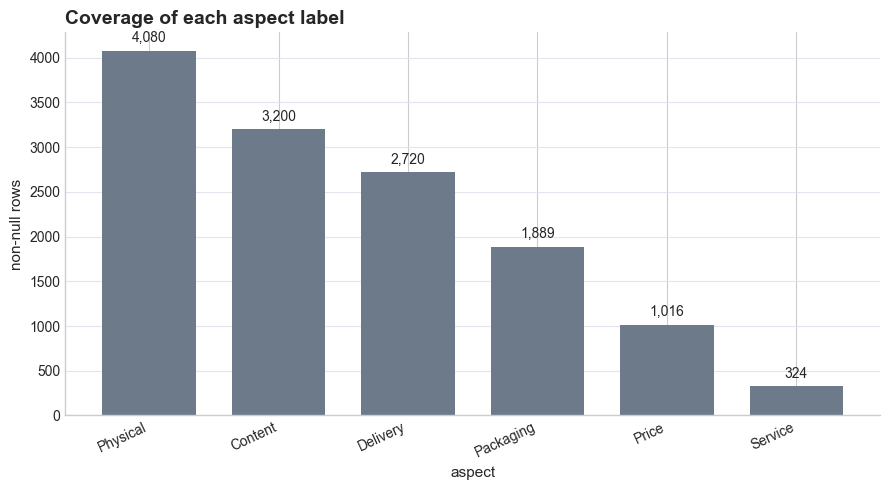

In [37]:
aspect_coverage = (
    df[ASPECT_COLS]
    .notna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
aspect_coverage.columns = ["aspect", "count"]

fig, ax = plt.subplots(figsize=(9, 5))
labels = [aspect.replace("as_", "").capitalize() for aspect in aspect_coverage["aspect"]]
values = aspect_coverage["count"].tolist()
x = np.arange(len(labels))
bars = ax.bar(x, values, color="#6c7a89", width=0.72)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
style_axes(ax)
ax.set_title("Coverage of each aspect label", loc="left")
ax.set_xlabel("aspect")
ax.set_ylabel("non-null rows")
annotate_vertical_bars(ax, bars, values, fmt="{:,.0f}")
plt.tight_layout()
plt.show()


## Stacked Bar Chart: Sentiment % Across 6 Aspects

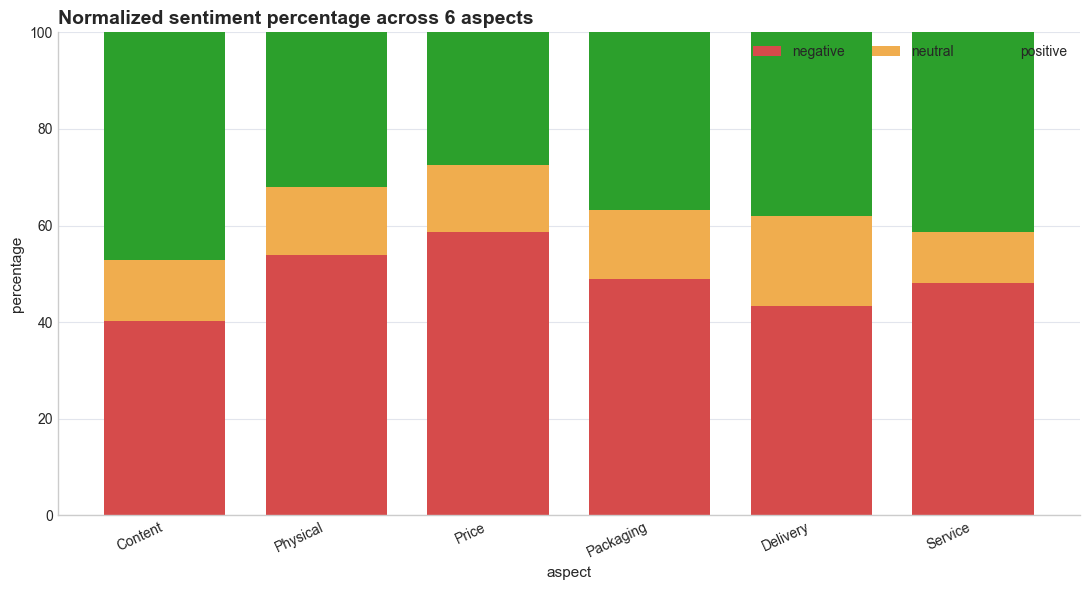

In [38]:
aspect_rows = []
for aspect in ASPECT_COLS:
    subset = df[[aspect, "sentiment_name"]].dropna()
    total = len(subset)
    if total == 0:
        continue
    counts = subset["sentiment_name"].value_counts().reindex(SENTIMENT_ORDER).fillna(0)
    for sentiment in SENTIMENT_ORDER:
        aspect_rows.append(
            {
                "aspect": aspect,
                "sentiment_name": sentiment,
                "percent": float(counts.get(sentiment, 0) * 100 / total),
            }
        )

aspect_pct = pd.DataFrame(aspect_rows)
aspect_pct_pivot = aspect_pct.pivot(index="aspect", columns="sentiment_name", values="percent").reindex(ASPECT_COLS).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
labels = [aspect.replace("as_", "").capitalize() for aspect in aspect_pct_pivot.index]
x = np.arange(len(labels))
bottom = np.zeros(len(labels))
for sentiment in SENTIMENT_ORDER:
    values = aspect_pct_pivot[sentiment].to_numpy() if sentiment in aspect_pct_pivot.columns else np.zeros(len(labels))
    ax.bar(x, values, bottom=bottom, color=SENTIMENT_COLORS[sentiment], label=sentiment, width=0.75)
    bottom += values
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
style_axes(ax)
ax.set_ylim(0, 100)
ax.set_title("Normalized sentiment percentage across 6 aspects", loc="left")
ax.set_xlabel("aspect")
ax.set_ylabel("percentage")
ax.legend(frameon=False, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()


## Scatter Plot: Attention vs Satisfaction

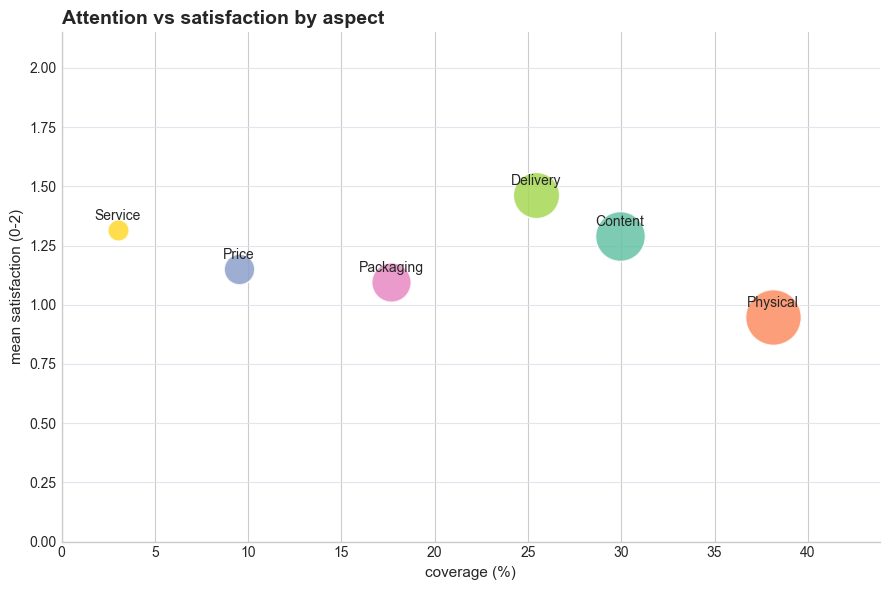

In [39]:
aspect_summary = []
for aspect in ASPECT_COLS:
    subset = df[[aspect]].dropna()
    if subset.empty:
        continue
    aspect_summary.append(
        {
            "aspect": aspect,
            "coverage": int(subset.shape[0]),
            "coverage_pct": float(subset.shape[0] * 100 / len(df)),
            "mean_score": float(subset[aspect].mean()),
        }
    )

aspect_summary = pd.DataFrame(aspect_summary)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.Set2.colors[: len(aspect_summary)]
sizes = 120 + (aspect_summary["coverage"].to_numpy() / aspect_summary["coverage"].max()) * 1500
for (_, row), color, size in zip(aspect_summary.iterrows(), colors, sizes):
    ax.scatter(row["coverage_pct"], row["mean_score"], s=size, color=color, alpha=0.85, edgecolors="white", linewidth=1.2)
    ax.text(
        row["coverage_pct"],
        row["mean_score"] + 0.03,
        row["aspect"].replace("as_", "").capitalize(),
        ha="center",
        va="bottom",
    )
style_axes(ax)
ax.set_title("Attention vs satisfaction by aspect", loc="left")
ax.set_xlabel("coverage (%)")
ax.set_ylabel("mean satisfaction (0-2)")
ax.set_xlim(0, max(aspect_summary["coverage_pct"]) * 1.15 if len(aspect_summary) else 1)
ax.set_ylim(0, 2.15)
plt.tight_layout()
plt.show()


## Radar Chart: 6 Aspect Strength

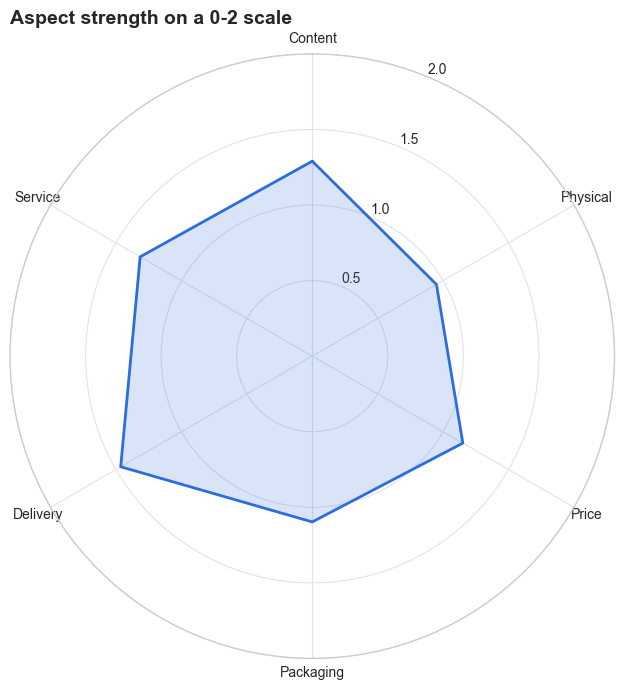

In [40]:
aspect_means = df[ASPECT_COLS].mean().fillna(0)
radar_labels = [aspect.replace("as_", "").capitalize() for aspect in ASPECT_COLS]
radar_values = list(aspect_means.values)
radar_values.append(radar_values[0])
angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles.append(angles[0])

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.plot(angles, radar_values, color="#2d6cdf", linewidth=2)
ax.fill(angles, radar_values, color="#2d6cdf", alpha=0.18)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_yticks([0.5, 1.0, 1.5, 2.0])
ax.set_ylim(0, 2)
ax.grid(color="#dfe3eb", linewidth=0.8)
ax.set_title("Aspect strength on a 0-2 scale", loc="left")
plt.tight_layout()
plt.show()


## Heatmap: Aspect Correlation Matrix

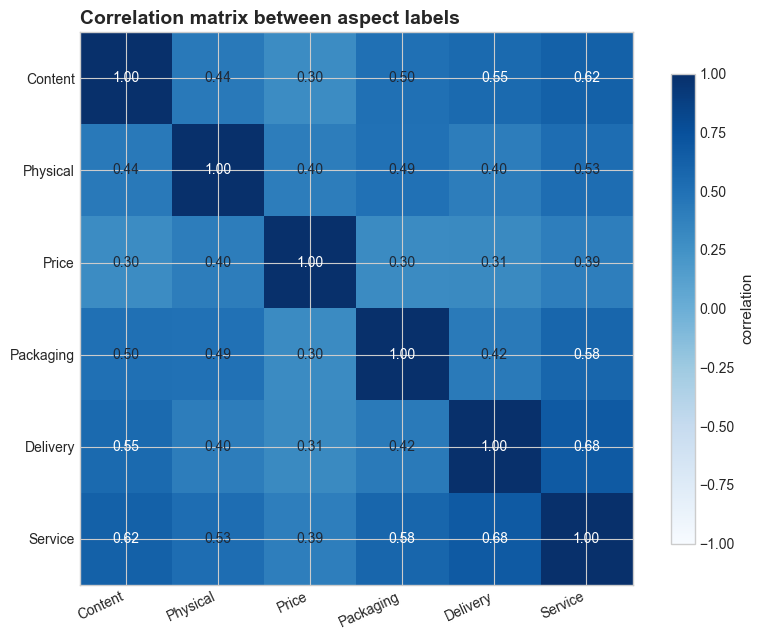

In [41]:
corr = df[ASPECT_COLS].corr()
heatmap_labels = [aspect.replace("as_", "").capitalize() for aspect in ASPECT_COLS]

fig, ax = plt.subplots(figsize=(8.5, 6.5))
im = ax.imshow(corr.values, cmap="Blues", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(heatmap_labels)))
ax.set_yticks(np.arange(len(heatmap_labels)))
ax.set_xticklabels(heatmap_labels, rotation=25, ha="right")
ax.set_yticklabels(heatmap_labels)
for i in range(len(heatmap_labels)):
    for j in range(len(heatmap_labels)):
        value = corr.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.55 else "#1f2937",
            fontsize=10,
        )
fig.colorbar(im, ax=ax, shrink=0.85, label="correlation")
ax.set_title("Correlation matrix between aspect labels", loc="left")
plt.tight_layout()
plt.show()


## Scatter Plot: Lexical Diversity vs Word Count

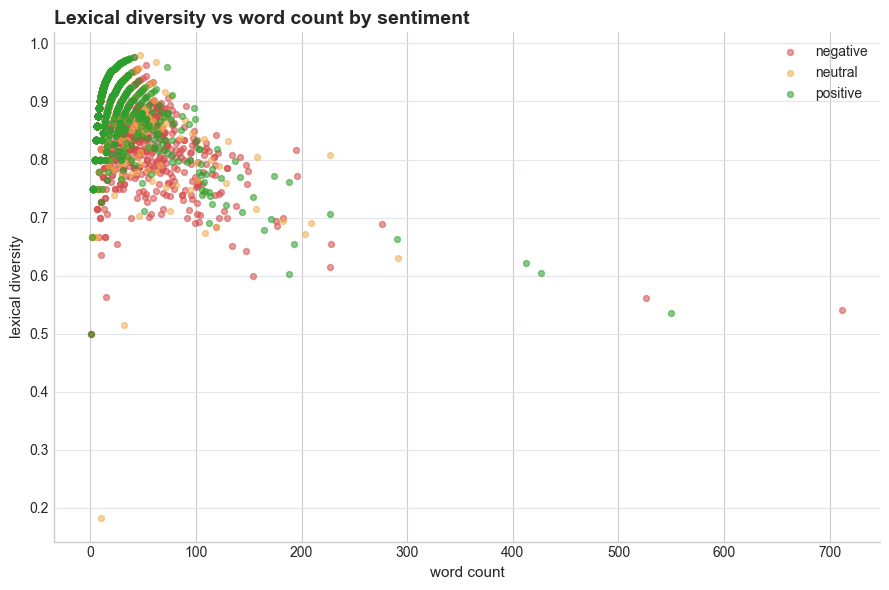

In [42]:
sample = df.sample(min(len(df), 3000), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for label in SENTIMENT_ORDER:
    subset = sample.loc[sample["sentiment_name"] == label]
    ax.scatter(
        subset["word_count"],
        subset["lexical_diversity"],
        s=18,
        alpha=0.55,
        label=label,
        color=SENTIMENT_COLORS[label],
    )
style_axes(ax)
ax.set_title("Lexical diversity vs word count by sentiment", loc="left")
ax.set_xlabel("word count")
ax.set_ylabel("lexical diversity")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [43]:
bigram_frames = {
    label: top_ngrams(
        sentiment_subset(df, label)["content"].map(normalize_text_for_ngrams).tolist(),
        ngram_range=(2, 2),
        top_n=15,
    )
    for label in SENTIMENT_ORDER
}

trigram_frames = {
    label: top_ngrams(
        sentiment_subset(df, label)["content"].map(normalize_text_for_ngrams).tolist(),
        ngram_range=(3, 3),
        top_n=10,
    )
    for label in SENTIMENT_ORDER
}

## Top 15 Bigrams Dashboard

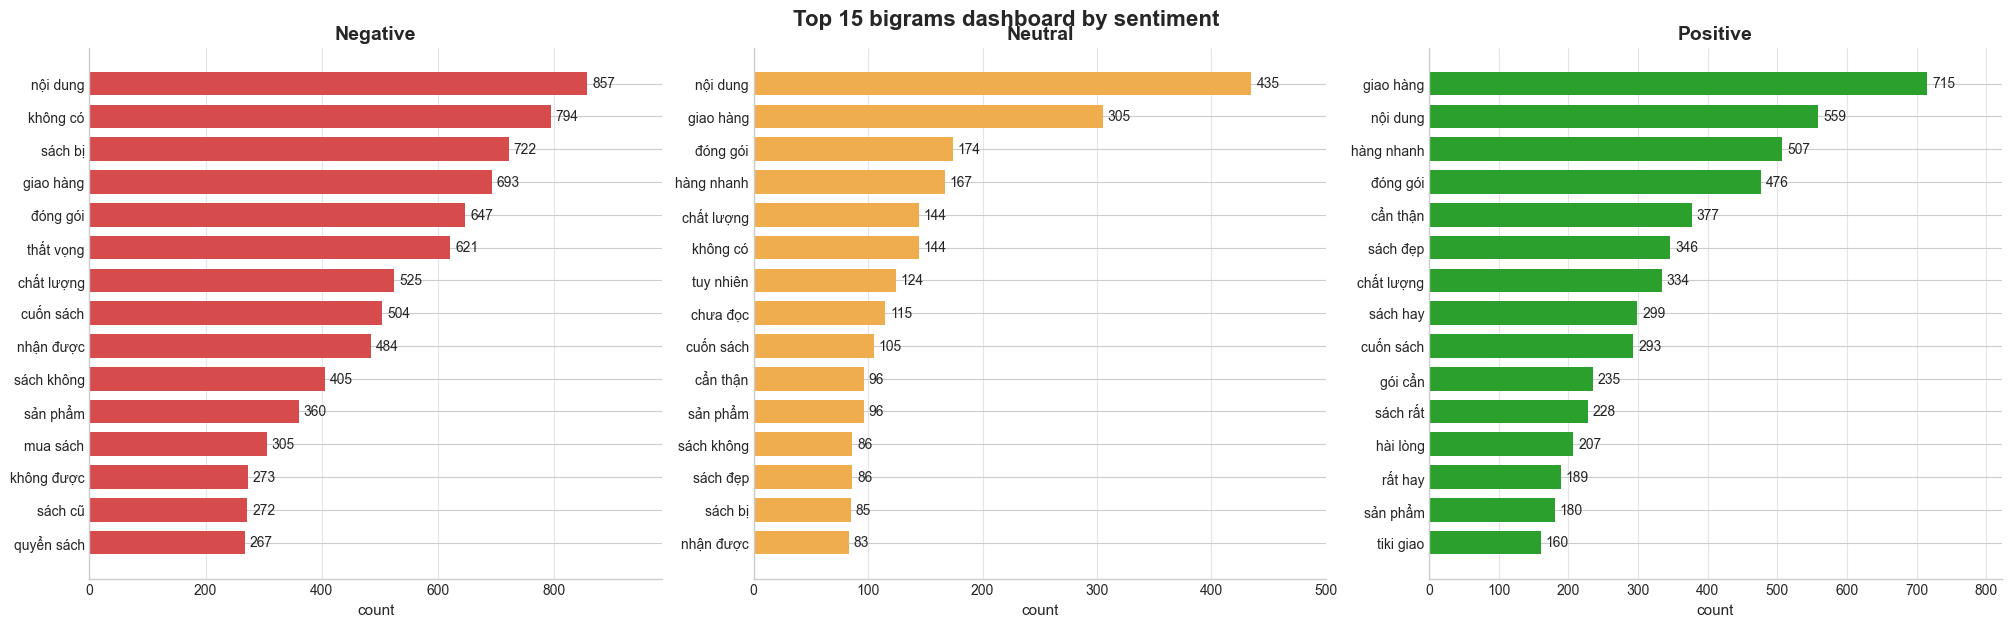

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for ax, label in zip(axes, SENTIMENT_ORDER):
    frame = bigram_frames[label].nlargest(15, "count").sort_values("count")
    y = np.arange(len(frame))
    counts = frame["count"].tolist()
    bars = ax.barh(y, counts, color=SENTIMENT_COLORS[label], height=0.72)
    ax.set_yticks(y)
    ax.set_yticklabels(frame["ngram"])
    style_axes(ax, grid_axis="x")
    ax.set_title(label.capitalize())
    ax.set_xlabel("count")
    ax.set_xlim(0, max(counts) * 1.15 if counts else 1)
    annotate_horizontal_bars(ax, bars, counts, fmt="{:,.0f}")
fig.suptitle("Top 15 bigrams dashboard by sentiment", y=1.02, fontsize=16, fontweight="bold")
plt.show()


## Top 10 Trigrams Dashboard

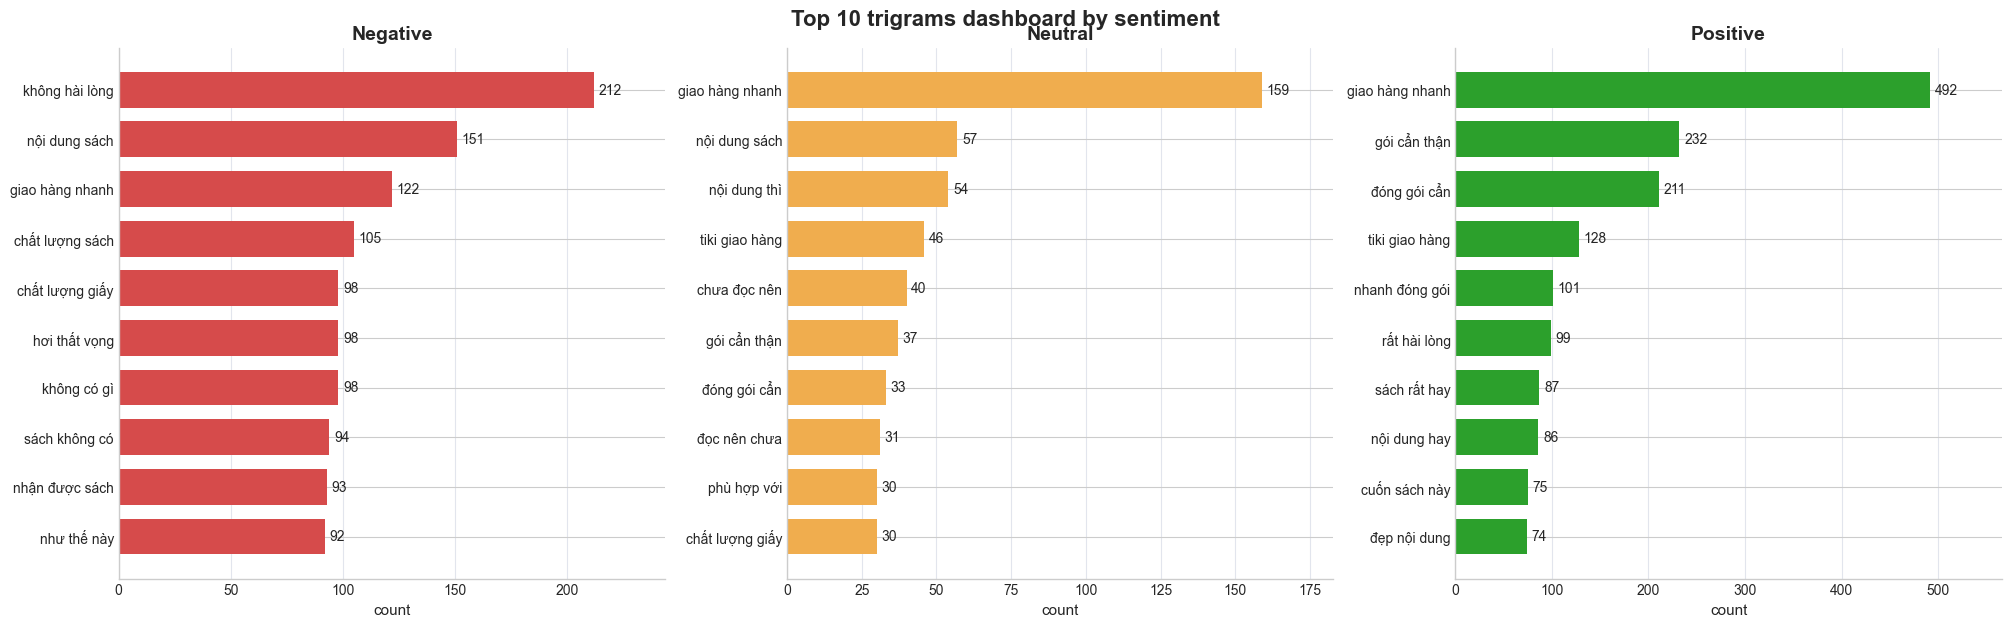

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for ax, label in zip(axes, SENTIMENT_ORDER):
    frame = trigram_frames[label].nlargest(10, "count").sort_values("count")
    y = np.arange(len(frame))
    counts = frame["count"].tolist()
    bars = ax.barh(y, counts, color=SENTIMENT_COLORS[label], height=0.72)
    ax.set_yticks(y)
    ax.set_yticklabels(frame["ngram"])
    style_axes(ax, grid_axis="x")
    ax.set_title(label.capitalize())
    ax.set_xlabel("count")
    ax.set_xlim(0, max(counts) * 1.15 if counts else 1)
    annotate_horizontal_bars(ax, bars, counts, fmt="{:,.0f}")
fig.suptitle("Top 10 trigrams dashboard by sentiment", y=1.02, fontsize=16, fontweight="bold")
plt.show()


## WordCloud Dashboard

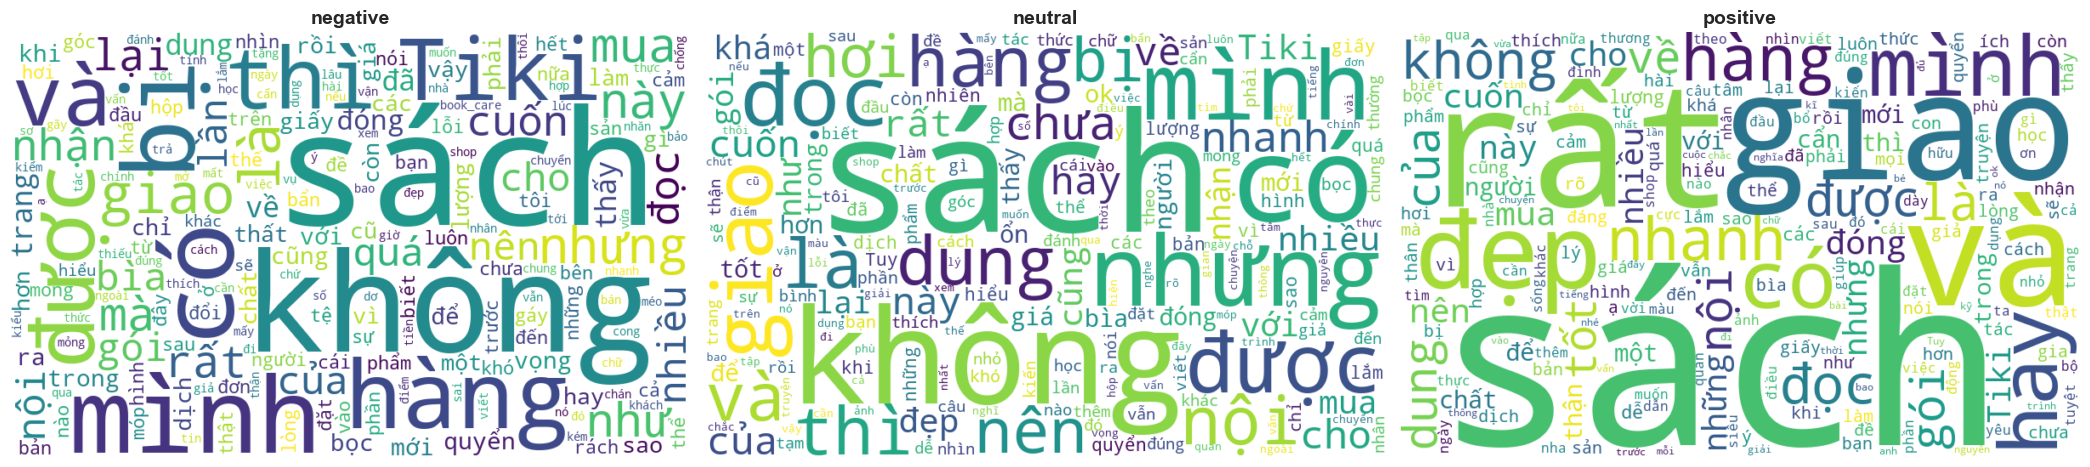

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, label in zip(axes, SENTIMENT_ORDER):
    text = " ".join(sentiment_subset(df, label)["content"].tolist())
    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        collocations=False,
        colormap="viridis",
    ).generate(text if text.strip() else "empty")
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3D Scatter: TF-IDF + t-SNE

In [47]:
sample_parts = []
for label in SENTIMENT_ORDER:
    subset = df.loc[df["sentiment_name"] == label]
    if subset.empty:
        continue
    sample_parts.append(subset.sample(min(len(subset), 300), random_state=42))

sample_3d = pd.concat(sample_parts, ignore_index=True)
texts_3d = sample_3d["content"].map(normalize_text_for_ngrams).tolist()

tfidf_3d = TfidfVectorizer(max_features=1200, ngram_range=(1, 2), min_df=2)
x_tfidf_3d = tfidf_3d.fit_transform(texts_3d)

n_components_3d = min(50, max(2, x_tfidf_3d.shape[1] - 1))
svd_3d = TruncatedSVD(n_components=n_components_3d, random_state=42)
x_reduced_3d = svd_3d.fit_transform(x_tfidf_3d)

perplexity_3d = min(30, max(5, len(sample_3d) // 10))
tsne_3d = TSNE(
    n_components=3,
    random_state=42,
    perplexity=perplexity_3d,
    init="pca",
    learning_rate="auto",
)
coords_3d = tsne_3d.fit_transform(x_reduced_3d)

plot_df_3d = sample_3d.copy()
plot_df_3d["x"] = coords_3d[:, 0]
plot_df_3d["y"] = coords_3d[:, 1]
plot_df_3d["z"] = coords_3d[:, 2]


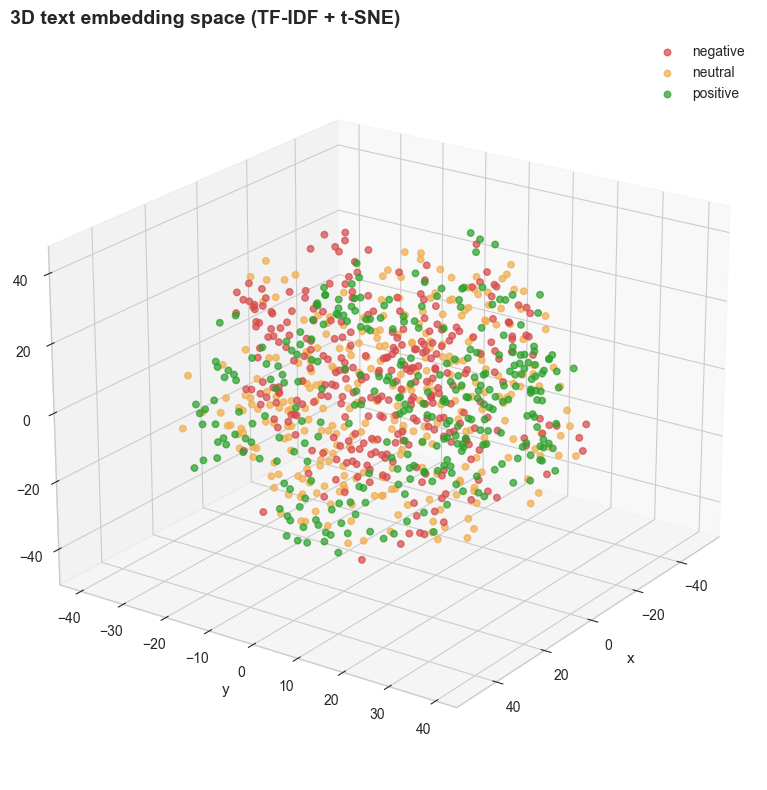

In [48]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
for label in SENTIMENT_ORDER:
    subset = plot_df_3d.loc[plot_df_3d["sentiment_name"] == label]
    ax.scatter(
        subset["x"],
        subset["y"],
        subset["z"],
        s=22,
        alpha=0.72,
        label=label,
        color=SENTIMENT_COLORS[label],
        depthshade=True,
    )
ax.set_title("3D text embedding space (TF-IDF + t-SNE)", loc="left")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(elev=22, azim=35)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Notes

- The dashboard is train-only.
- Emoji counts are computed from `content_raw`.
- N-grams, word clouds, and embeddings are computed from cleaned `content`.
- GitHub preview uses static Matplotlib outputs and the preview snapshot cell at the top.
